In [ ]:
import numpy as np
import pandas as pd
import random


In [ ]:
areas = ["Chennai", "Madurai", "Coimbatore", "Trichy"]
area_types = ["Urban", "Suburban", "Rural"]
networks = ["2G", "4G", "5G"]


In [ ]:
def generate_sample():
    area = random.choice(areas)
    area_type = random.choice(area_types)
    network = random.choice(networks)

    freq = random.choice([900, 1800, 2400, 3500])   # MHz
    distance = round(random.uniform(10, 500), 2)  # meters
    tx_power = round(random.uniform(20, 50), 2)   # dBm

    # Path loss model (simplified)
    path_loss = 32.44 + 20*np.log10(freq) + 20*np.log10(distance/1000)

    rf_power = tx_power - path_loss

    # RF to DC conversion (non-linear)
    dc_voltage = max(0, 0.08 * rf_power + 3 + np.random.normal(0, 0.5))

    return [area, area_type, network, freq, distance, tx_power, rf_power, dc_voltage]


In [ ]:
data = []
for i in range(3000):
    data.append(generate_sample())

columns = ["Area_Name", "Area_Type", "Network",
           "Frequency_MHz", "Distance_m",
           "Tx_Power_dBm", "RF_Power_dBm", "DC_Output_Voltage"]

df = pd.DataFrame(data, columns=columns)


In [ ]:
df.to_csv("rf_energy_harvesting_dataset.csv", index=False)
print("Dataset saved!")


Dataset saved!


In [ ]:
df.head()


,Area_Name,Area_Type,Network,Frequency_MHz,Distance_m,Tx_Power_dBm,RF_Power_dBm,DC_Output_Voltage
0,Trichy,Rural,4G,900,118.00,41.67,-31.292490,0.151513
1,Madurai,Urban,2G,900,37.15,49.68,-13.244027,1.414080
2,Chennai,Rural,2G,3500,404.16,48.03,-47.422427,0.000000
3,Chennai,Rural,5G,3500,105.36,48.75,-35.024876,1.134992
4,Trichy,Urban,4G,3500,211.41,46.77,-43.053871,0.042116


In [ ]:
df.describe()


,Frequency_MHz,Distance_m,Tx_Power_dBm,RF_Power_dBm,DC_Output_Voltage
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,2127.666667,257.310210,34.884307,-49.246466,0.119725
std,947.093915,141.248215,8.694902,11.990765,0.333846
min,900.000000,10.160000,20.040000,-76.169936,0.000000
25%,900.000000,133.767500,27.447500,-58.313106,0.000000
50%,1800.000000,259.580000,34.825000,-49.676424,0.000000
75%,2400.000000,380.495000,42.482500,-40.736100,0.000000
max,3500.000000,499.990000,50.000000,-3.537659,3.006652


In [ ]:
import pandas as pd

df = pd.read_csv("rf_energy_harvesting_dataset.csv")
df.head()


,Area_Name,Area_Type,Network,Frequency_MHz,Distance_m,Tx_Power_dBm,RF_Power_dBm,DC_Output_Voltage
0,Trichy,Rural,4G,900,118.00,41.67,-31.292490,0.151513
1,Madurai,Urban,2G,900,37.15,49.68,-13.244027,1.414080
2,Chennai,Rural,2G,3500,404.16,48.03,-47.422427,0.000000
3,Chennai,Rural,5G,3500,105.36,48.75,-35.024876,1.134992
4,Trichy,Urban,4G,3500,211.41,46.77,-43.053871,0.042116


In [ ]:
import pandas as pd

data = pd.read_csv("rf_energy_harvesting_dataset.csv")

print(data.head())

print(data.info())

print(data.shape)

  Area_Name Area_Type Network  Frequency_MHz  Distance_m  Tx_Power_dBm  \
0    Trichy     Rural      4G            900      118.00         41.67   
1   Madurai     Urban      2G            900       37.15         49.68   
2   Chennai     Rural      2G           3500      404.16         48.03   
3   Chennai     Rural      5G           3500      105.36         48.75   
4    Trichy     Urban      4G           3500      211.41         46.77   

   RF_Power_dBm  DC_Output_Voltage  
0    -31.292490           0.151513  
1    -13.244027           1.414080  
2    -47.422427           0.000000  
3    -35.024876           1.134992  
4    -43.053871           0.042116  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area_Name          3000 non-null   object 
 1   Area_Type          3000 non-null   object 
 2   Network            3000 non-nu

In [ ]:
import pandas as pd
import numpy as np

# Load the dataset
data = pd.read_csv("rf_energy_harvesting_dataset.csv")

# Check for missing values
print(data.isnull().sum())

# Remove duplicate records
data = data.drop_duplicates()

# Fill missing values with mean value for numeric columns only
data = data.fillna(data.select_dtypes(include=np.number).mean())

# Display cleaned dataset
print(data.head())

Area_Name            0
Area_Type            0
Network              0
Frequency_MHz        0
Distance_m           0
Tx_Power_dBm         0
RF_Power_dBm         0
DC_Output_Voltage    0
dtype: int64
  Area_Name Area_Type Network  Frequency_MHz  Distance_m  Tx_Power_dBm  \
0    Trichy     Rural      4G            900      118.00         41.67   
1   Madurai     Urban      2G            900       37.15         49.68   
2   Chennai     Rural      2G           3500      404.16         48.03   
3   Chennai     Rural      5G           3500      105.36         48.75   
4    Trichy     Urban      4G           3500      211.41         46.77   

   RF_Power_dBm  DC_Output_Voltage  
0    -31.292490           0.151513  
1    -13.244027           1.414080  
2    -47.422427           0.000000  
3    -35.024876           1.134992  
4    -43.053871           0.042116  


In [ ]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Load dataset
data = pd.read_csv("rf_energy_harvesting_dataset.csv")

# Create label encoder object
le = LabelEncoder()

# Apply label encoding to categorical columns
data['Area_Name'] = le.fit_transform(data['Area_Name'])
data['Area_Type'] = le.fit_transform(data['Area_Type'])
data['Network'] = le.fit_transform(data['Network'])

# Display encoded dataset
print(data.head())

   Area_Name  Area_Type  Network  Frequency_MHz  Distance_m  Tx_Power_dBm  \
0          3          0        1            900      118.00         41.67   
1          2          2        0            900       37.15         49.68   
2          0          0        0           3500      404.16         48.03   
3          0          0        2           3500      105.36         48.75   
4          3          2        1           3500      211.41         46.77   

   RF_Power_dBm  DC_Output_Voltage  
0    -31.292490           0.151513  
1    -13.244027           1.414080  
2    -47.422427           0.000000  
3    -35.024876           1.134992  
4    -43.053871           0.042116  


In [ ]:
from sklearn.preprocessing import LabelEncoder

le_area = LabelEncoder()
le_type = LabelEncoder()
le_net = LabelEncoder()

df["Area_Name"] = le_area.fit_transform(df["Area_Name"])
df["Area_Type"] = le_type.fit_transform(df["Area_Type"])
df["Network"] = le_net.fit_transform(df["Network"])


In [ ]:
X = df[["Area_Name", "Area_Type", "Network",
        "Frequency_MHz", "Distance_m",
        "Tx_Power_dBm", "RF_Power_dBm"]]

y = df["DC_Output_Voltage"]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)


RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

y_pred = rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R² Score:", r2)
print("RMSE:", rmse)


R² Score: 0.6619641217640461
RMSE: 0.2153173568840259


In [ ]:
# =========================
# 1. Import Libraries
# =========================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import pickle

# =========================
# 2. Load Dataset
# =========================
df = pd.read_csv("/content/rf_energy_harvesting_dataset.csv")

# =========================
# 3. Physics based FSPL
# FSPL = 32.44 + 20log10(f) + 20log10(d)
# =========================
df["FSPL"] = 32.44 + 20*np.log10(df["Frequency_MHz"]) + 20*np.log10(df["Distance_m"])

# =========================
# 4. Log transform
# =========================
df["log_distance"] = np.log(df["Distance_m"])
df["log_rf"] = np.log(np.abs(df["RF_Power_dBm"]))

# =========================
# 5. Features & Target
# =========================
X = df[[
    "Area_Name",
    "Area_Type",
    "Network",
    "Frequency_MHz",
    "Distance_m",
    "Tx_Power_dBm",
    "FSPL",
    "log_distance"
]]

y = df["log_rf"]

# =========================
# 6. Categorical + Numerical
# =========================
cat_features = ["Area_Name", "Area_Type", "Network"]
num_features = ["Frequency_MHz", "Distance_m", "Tx_Power_dBm", "FSPL", "log_distance"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ("num", "passthrough", num_features)
    ]
)

# =========================
# 7. High Accuracy Random Forest
# =========================
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=25,
    min_samples_leaf=2,
    min_samples_split=5,
    max_features="sqrt",
    bootstrap=True,
    random_state=42
)

model = Pipeline([
    ("preprocess", preprocessor),
    ("rf", rf)
])

# =========================
# 8. Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 9. Train Model
# =========================
model.fit(X_train, y_train)

# =========================
# 10. Evaluate
# =========================
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R² Score:", r2)
print(" RMSE:", rmse)

# =========================
# 11. Save Model
# =========================
with open("rf_energy_model.pkl", "wb") as f:
    pickle.dump(model, f)

print(" Model saved as rf_energy_model.pkl")

R² Score: 0.9458778498502107
 RMSE: 0.06723501550344448
 Model saved as rf_energy_model.pkl


In [ ]:
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline

# Support Vector Regression model
svr = Pipeline([
    ("preprocess", preprocessor),
    ("svr", SVR(kernel="rbf", C=10, epsilon=0.1))
])

# Train SVR
svr.fit(X_train, y_train)

# Predict
y_pred_svr = svr.predict(X_test)

# Metrics
r2_svr = r2_score(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))

print("\n--- Model Comparison ---")
print("Random Forest R2:", r2)
print("Random Forest RMSE:", rmse)

print("SVR R2:", r2_svr)
print("SVR RMSE:", rmse_svr)



--- Model Comparison ---
Random Forest R2: 0.9458778498502107
Random Forest RMSE: 0.06723501550344448
SVR R2: 0.85526751703696
SVR RMSE: 0.10994892685134003


In [ ]:
df.columns

Index(['Area_Name', 'Area_Type', 'Network', 'Frequency_MHz', 'Distance_m',
       'Tx_Power_dBm', 'RF_Power_dBm', 'DC_Output_Voltage', 'FSPL',
       'log_distance', 'log_rf'],
      dtype='object')

<Figure size 800x500 with 0 Axes>

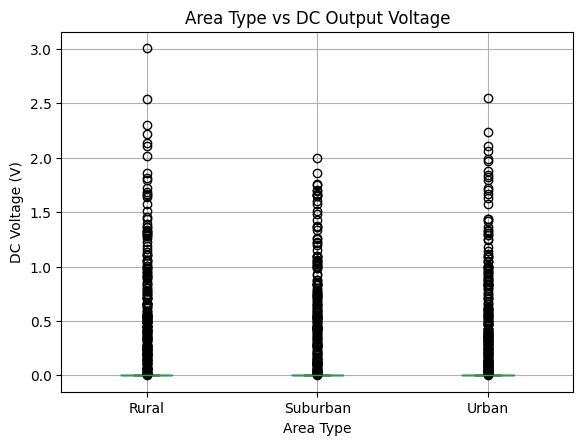

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("rf_energy_harvesting_dataset.csv")

plt.figure(figsize=(8,5))
df.boxplot(column="DC_Output_Voltage", by="Area_Type")
plt.title("Area Type vs DC Output Voltage")
plt.suptitle("")
plt.xlabel("Area Type")
plt.ylabel("DC Voltage (V)")
plt.grid(True)
plt.show()


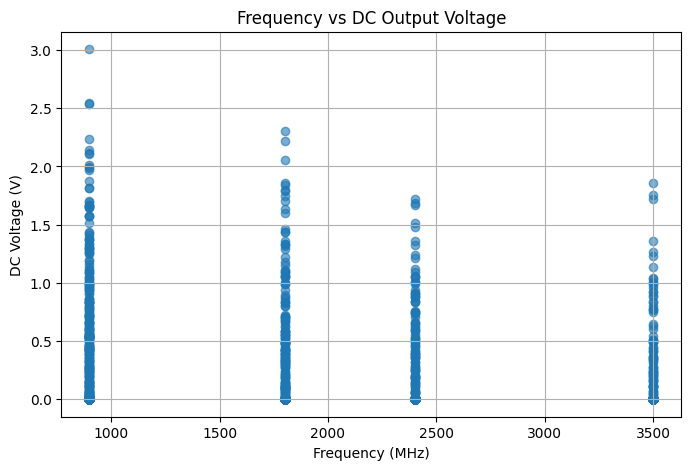

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df["Frequency_MHz"], df["DC_Output_Voltage"], alpha=0.6)
plt.title("Frequency vs DC Output Voltage")
plt.xlabel("Frequency (MHz)")
plt.ylabel("DC Voltage (V)")
plt.grid(True)
plt.show()


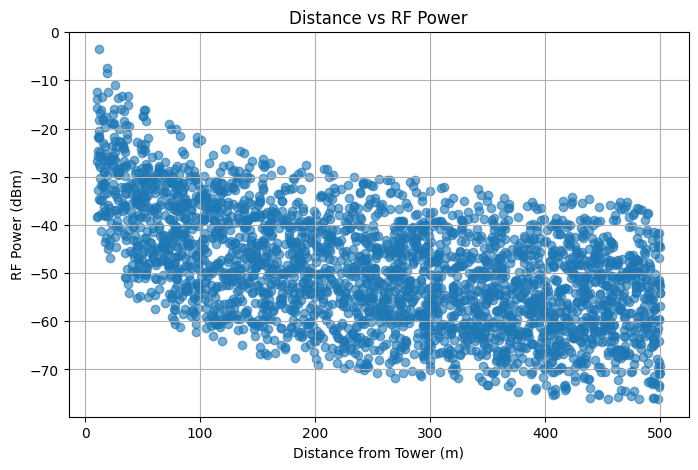

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df["Distance_m"], df["RF_Power_dBm"], alpha=0.6)
plt.title("Distance vs RF Power")
plt.xlabel("Distance from Tower (m)")
plt.ylabel("RF Power (dBm)")
plt.grid(True)
plt.show()


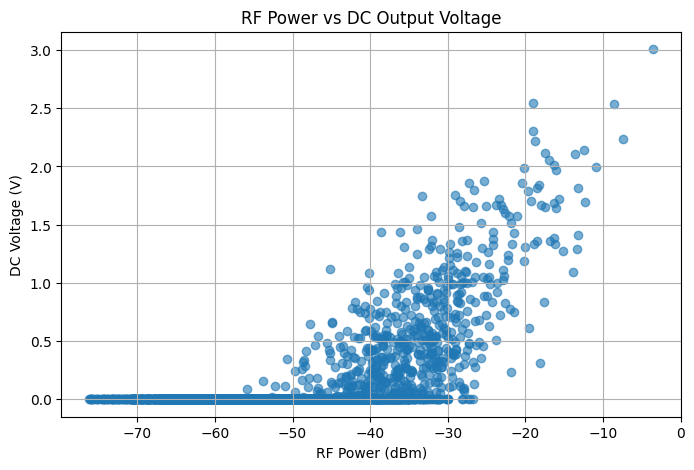

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df["RF_Power_dBm"], df["DC_Output_Voltage"], alpha=0.6)
plt.title("RF Power vs DC Output Voltage")
plt.xlabel("RF Power (dBm)")
plt.ylabel("DC Voltage (V)")
plt.grid(True)
plt.show()


In [ ]:
import os
os.listdir()


['.config',
 'rf_energy_harvesting_dataset.csv',
 'rf_energy_model.pkl',
 'sample_data']

In [ ]:
!pip install gradio


In [ ]:
pip install folium


In [ ]:
import folium
import numpy as np

# Tower location (example: Madurai)
tower_lat = 9.9252
tower_lon = 78.1198

# Parameters
tx_power = 43   # dBm
frequency = 1800  # MHz

# FSPL function
def fspl(f, d):
    return 32.44 + 20*np.log10(f) + 20*np.log10(d)

# Create map
m = folium.Map(location=[tower_lat, tower_lon], zoom_start=13)

# Mark tower
folium.Marker([tower_lat, tower_lon], popup="Mobile Tower").add_to(m)

# Plot RF points around tower
for d in range(100, 1000, 100):  # 100m to 1km
    loss = fspl(frequency, d)
    rf_power = tx_power - loss

    # Fake coordinate shift
    lat = tower_lat + d*0.00001
    lon = tower_lon + d*0.00001

    color = "green" if rf_power > -40 else "orange" if rf_power > -70 else "red"

    folium.CircleMarker(
        location=[lat, lon],
        radius=8,
        popup=f"Distance: {d}m\nRF: {round(rf_power,2)} dBm",
        color=color,
        fill=True
    ).add_to(m)

# Save map
m.save("rf_real_map.html")
print("Map saved as rf_real_map.html")


Map saved as rf_real_map.html


In [ ]:
!pip install folium


In [ ]:
import folium
import random
import math

# City base coordinates
cities = {
    "Chennai": [13.0827, 80.2707],
    "Madurai": [9.9252, 78.1198],
    "Coimbatore": [11.0168, 76.9558],
    "Tirunelveli": [8.7139, 77.7567]
}

# Create map
m = folium.Map(location=[11,78], zoom_start=7)

# Function to simulate RF power
def rf_power(distance):
    tx = 43  # dBm
    fspl = 32.44 + 20*math.log10(1800) + 20*math.log10(distance)
    return tx - fspl

# For each city
for city, base in cities.items():

    # Generate 5 towers per city
    for i in range(5):

        lat = base[0] + random.uniform(-0.02, 0.02)
        lon = base[1] + random.uniform(-0.02, 0.02)

        distance = random.randint(100,800)
        power = rf_power(distance)

        # Color logic
        if power > -40:
            color = "red"
        elif power > -70:
            color = "orange"
        else:
            color = "green"

        # Tower marker
        folium.Marker(
            [lat,lon],
            popup=f"""
            City: {city}<br>
            Tower: {i+1}<br>
            Distance: {distance} m<br>
            RF Power: {round(power,2)} dBm
            """,
            icon=folium.Icon(color=color)
        ).add_to(m)

        # Coverage circle
        folium.Circle(
            location=[lat,lon],
            radius=distance,
            color=color,
            fill=True,
            fill_opacity=0.2
        ).add_to(m)

m.save("rf_real_coverage_map.html")
print("Saved as rf_real_coverage_map.html")

Saved as rf_real_coverage_map.html


In [ ]:
import gradio as gr
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
import random   # ✅ NEW

# ---------------- LOAD MODEL ----------------
with open("rf_energy_model.pkl","rb") as f:
    model = pickle.load(f)

df = pd.read_csv("rf_energy_harvesting_dataset.csv")

areas = df["Area_Name"].unique().tolist()
types = df["Area_Type"].unique().tolist()
networks = df["Network"].unique().tolist()

# ---------------- LOGIN DATABASE ----------------
users_db = {"admin":"1234","abi":"rf2026"}
active_users = []

def login(username,password):

    if username in users_db and users_db[username]==password:

        if username not in active_users:
            active_users.append(username)

        return "Login Successful"

    else:
        return "Invalid Username or Password"


def show_users():
    return f"Active Users : {len(active_users)}"


# ---------------- CITY COORDINATES ----------------
city_coords = {
    "Chennai": [13.0827, 80.2707],
    "Madurai": [9.9252, 78.1198],
    "Coimbatore": [11.0168, 76.9558],
    "Tirunelveli": [8.7139, 77.7567],
    "Trichy": [10.7905, 78.7047]
}

# ---------------- PREDICTION ----------------
def predict_all(area,atype,network,freq,dist,tx):

    dist_km = dist/1000

    fspl = 32.44 + 20*np.log10(freq) + 20*np.log10(dist_km)

    log_dist = np.log10(dist)

    X = pd.DataFrame([{
        "Area_Name":area,
        "Area_Type":atype,
        "Network":network,
        "Frequency_MHz":freq,
        "Distance_m":dist,
        "Tx_Power_dBm":tx,
        "FSPL":fspl,
        "log_distance":log_dist
    }])

    dc = float(model.predict(X)[0])

    R = 1000
    current_mA = (dc/R)*1000
    power_mW = dc*current_mA

    plt.figure()
    plt.bar(["DC Voltage"],[dc])
    plt.ylim(0,5)
    plt.title("Predicted DC Voltage")
    plt.savefig("bar.png")
    plt.close()

    return round(dc,3),round(current_mA,3),round(power_mW,3),"bar.png"


# ---------------- MAP ----------------
def generate_real_map(freq,tx):

    m = folium.Map(location=[11.5,78.5],zoom_start=7)

    city_coords = {
        "Chennai": [13.0827, 80.2707],
        "Trichy": [10.7905, 78.7047],
        "Coimbatore": [11.0168, 76.9558],
        "Madurai": [9.9252, 78.1198]
    }

    import random

    for city, coord in city_coords.items():

        # City marker (title)
        folium.Marker(
            location=coord,
            popup=f"<b>{city}</b><br>RF Towers Region",
            icon=folium.Icon(color="blue", icon="info-sign")
        ).add_to(m)

        tower_count = random.randint(4,7)

        for i in range(tower_count):

            lat = coord[0] + random.uniform(-0.02,0.02)
            lon = coord[1] + random.uniform(-0.02,0.02)

            distance = random.randint(100,800)
            d_km = distance / 1000

            fspl = 32.44 + 20*np.log10(freq) + 20*np.log10(d_km)
            rf_power = tx - fspl

            # Color logic
            if rf_power > -60:
                color = "red"
            elif rf_power > -80:
                color = "orange"
            else:
                color = "green"

            # Tower circle
            folium.Circle(
                location=[lat,lon],
                radius=distance,
                color=color,
                fill=True,
                fill_opacity=0.4
            ).add_to(m)

            # Click popup
            folium.Marker(
                location=[lat,lon],
                popup=f"""
                <b>City:</b> {city}<br>
                <b>Tower:</b> {i+1}<br>
                <b>Frequency:</b> {freq} MHz<br>
                <b>Distance:</b> {distance} m<br>
                <b>RF Power:</b> {round(rf_power,2)} dBm
                """,
                icon=folium.Icon(color=color)
            ).add_to(m)

    return m._repr_html_()
# ---------------- AI ADVISOR ----------------
def ai_advisor(freq, dist, tx):

    suggestions = []
    score = 0

    # -------- DISTANCE --------
    if dist > 500:
        suggestions.append("⚠️ Distance is very high. RF signal loss will be significant.")
        suggestions.append("👉 Reduce distance or use signal booster.")
    elif dist > 300:
        suggestions.append("📡 Moderate distance. Signal strength may reduce slightly.")
        suggestions.append("👉 Try to keep devices closer for better efficiency.")
        score += 1
    else:
        suggestions.append(" Distance is optimal for RF energy harvesting.")
        score += 2

    # -------- FREQUENCY --------
    if freq > 2500:
        suggestions.append("⚠️ High frequency causes higher path loss.")
        suggestions.append("👉 Use lower frequency bands like 900–1800 MHz.")
    elif freq > 1800:
        suggestions.append("📶 Medium-high frequency. Balanced performance.")
        score += 1
    else:
        suggestions.append(" Frequency is suitable for better penetration.")
        score += 2

    # -------- TX POWER --------
    if tx < 30:
        suggestions.append("⚠️ Transmitter power is low.")
        suggestions.append("👉 Increase Tx power for better RF harvesting.")
    elif tx < 40:
        suggestions.append("🔋 Moderate transmitter power.")
        score += 1
    else:
        suggestions.append(" Strong transmitter power.")
        score += 2

    # -------- COMBINED LOGIC --------
    if dist > 400 and tx < 35:
        suggestions.append("❗ High distance + Low power = Poor performance.")
        suggestions.append("👉 Either reduce distance or increase power.")

    if freq > 2000 and dist > 300:
        suggestions.append("❗ High frequency + long distance = signal loss.")
        suggestions.append("👉 Use lower frequency or reduce range.")

    # -------- FINAL STATUS --------
    if score >= 5:
        status = "🟢 GOOD"
    elif score >= 3:
        status = "🟡 AVERAGE"
    else:
        status = "🔴 POOR"

    # -------- FINAL SUMMARY --------
    suggestions.append("\n==============================")
    suggestions.append(f" Overall System Performance: {status}")
    suggestions.append(f" Efficiency Score: {score}/6")

    if status == "🟢 GOOD":
        suggestions.append("🚀 System is well optimized. No major changes needed.")
    elif status == "🟡 AVERAGE":
        suggestions.append("⚙️ Minor improvements can increase performance.")
    else:
        suggestions.append("🚨 System needs optimization for better RF energy harvesting.")

    return "\n".join(suggestions)


def smart_decision_system(mode, m1,m2,m3,m4,m5,m6):

    html = "<h2 style='color:white;text-align:center;'> Smart Energy Control</h2>"
    html += "<div style='display:flex;flex-wrap:wrap;justify-content:center;'>"

    import random

    devices = [
        ("Sensor 📡", "HIGH", m1),
        ("Street Light 💡", "MEDIUM", m2),
        ("Fan 🌀", "LOW", m3),
        ("Camera 🎥", "HIGH", m4),
        ("Charger 🔋", "LOW", m5),
        ("IoT Device 📶", "MEDIUM", m6)
    ]

    for i, (device, priority, manual_state) in enumerate(devices):

        voltage = round(random.uniform(0.3,3.5),2)

        # -------- AUTO LOGIC --------
        if voltage > 2:
            auto_status = "ON"
        elif voltage > 1:
            auto_status = "ON" if priority in ["HIGH","MEDIUM"] else "OFF"
        else:
            auto_status = "ON" if priority == "HIGH" else "OFF"

        # -------- MANUAL OVERRIDE --------
        if mode == "Manual":
            status = manual_state
        else:
            status = auto_status

        # COLOR
        color = "#00ff88" if status == "ON" else "#ff4444"

        html += f"""
        <div style="
            width:250px;
            margin:15px;
            padding:20px;
            border-radius:20px;
            background:rgba(0,0,0,0.7);
            color:white;
            text-align:center;
            box-shadow:0px 0px 20px {color};
        ">
            <h3>{device}</h3>
            <h2>{voltage} V</h2>
            <p>Priority: {priority}</p>
            <h3 style='color:{color};'>{status}</h3>
        </div>
        """

    html += "</div>"

    return html



# ---------------- UI ----------------
with gr.Blocks(css="""
.gradio-container {
background-image:url('https://images.unsplash.com/photo-1509395176047-4a66953fd231');
background-size:cover;
background-position:center;
}
""") as app:

    gr.Markdown("# RF Energy Harvesting System")

    with gr.Tabs():

        # -------- LOGIN PAGE --------
        with gr.Tab("Login Page"):

            user = gr.Textbox(label="Username")
            pwd = gr.Textbox(label="Password",type="password")

            login_btn = gr.Button("Login")

            login_status = gr.Textbox(label="Status")

            user_btn = gr.Button("Check Active Users")

            user_display = gr.Textbox(label="User Count")


        # -------- INPUT PAGE --------
        with gr.Tab("Input Page"):

            a = gr.Dropdown(areas,label="Area")
            t = gr.Dropdown(types,label="Area Type")
            n = gr.Dropdown(networks,label="Network")

            f = gr.Number(label="Frequency MHz",value=1800)
            d = gr.Number(label="Distance m",value=200)
            tx = gr.Number(label="Tx Power dBm",value=43)

            submit_btn = gr.Button("Predict Result")
            map_btn = gr.Button("Generate RF Map")


        # -------- RESULT PAGE --------
        with gr.Tab("Result Page"):

            dc_out = gr.Number(label="Predicted DC Voltage")
            cur_out = gr.Number(label="Wireless Current (mA)")
            pow_out = gr.Number(label="Wireless Power (mW)")
            bar_img = gr.Image(label="Voltage Graph")


        # -------- MAP PAGE --------
        with gr.Tab("Map Page"):

            map_html = gr.HTML()


        # -------- AI ADVISOR --------
        with gr.Tab("AI Advisor"):

            ai_freq = gr.Number(label="Frequency MHz",value=1800)
            ai_dist = gr.Number(label="Distance m",value=200)
            ai_tx = gr.Number(label="Tx Power dBm",value=43)

            ai_btn = gr.Button("Run AI Analysis")

            ai_output = gr.Textbox(label="AI Recommendation",lines=5)


        #-----------smart ddecision---------
        with gr.Tab("Smart Control"):
            mode = gr.Radio(["Auto","Manual"], label="Select Mode", value="Auto")

            m1 = gr.Radio(["ON","OFF"], label="Sensor 📡", value="ON")
            m2 = gr.Radio(["ON","OFF"], label="Street Light 💡", value="ON")
            m3 = gr.Radio(["ON","OFF"], label="Fan 🌀", value="OFF")
            m4 = gr.Radio(["ON","OFF"], label="Camera 🎥", value="ON")
            m5 = gr.Radio(["ON","OFF"], label="Charger 🔋", value="OFF")
            m6 = gr.Radio(["ON","OFF"], label="IoT Device 📶", value="ON")

            dec_btn = gr.Button("Run System")
            dec_output = gr.HTML()


    # -------- BUTTON CONNECTIONS --------

    login_btn.click(login,inputs=[user,pwd],outputs=login_status)

    user_btn.click(show_users,outputs=user_display)

    submit_btn.click(
        predict_all,
        inputs=[a,t,n,f,d,tx],
        outputs=[dc_out,cur_out,pow_out,bar_img]
    )

    map_btn.click(
        generate_real_map,
        inputs=[f,tx],
        outputs=map_html
    )

    ai_btn.click(
        ai_advisor,
        inputs=[ai_freq,ai_dist,ai_tx],
        outputs=ai_output
    )
    dec_btn.click(
    smart_decision_system,
    inputs=[mode, m1,m2,m3,m4,m5,m6],
    outputs=dec_output
)


    app.launch(share=True)

/tmp/ipykernel_561/30979748.py:286: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css="""


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://461045c856b04047ad.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
